<a href="https://colab.research.google.com/github/nicolejanoff/Test/blob/main/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Concentration: 0.0025 µM
Expected response: 0.9999972222299383
Error: 0.004106780925486331
Observed response: 1.0041040031554247

Concentration: 0.008 µM
Expected response: 0.9999715563646189
Error: -0.01256135851257599
Observed response: 0.9874101978520429

Concentration: 0.025 µM
Expected response: 0.9997222993612885
Error: 0.006609935539192408
Observed response: 1.0063322349004808

Concentration: 0.08 µM
Expected response: 0.9971636234710158
Error: -0.006824303555201962
Observed response: 0.9903393199158139

Concentration: 0.25 µM
Expected response: 0.972972972972973
Error: 0.014666041087327521
Observed response: 0.9876390140603005

Concentration: 0.8 µM
Expected response: 0.7785467128027681
Error: -0.001273714258031537
Observed response: 0.7772729985447365

Concentration: 2.53 µM
Expected response: 0.26008854570044737
Error: 0.0004662527438337721
Observed response: 0.26055479844428114

Concentration: 8 µM
Expected response: 0.033962264150943396
Error: -4.497134525851307e-05
Observe

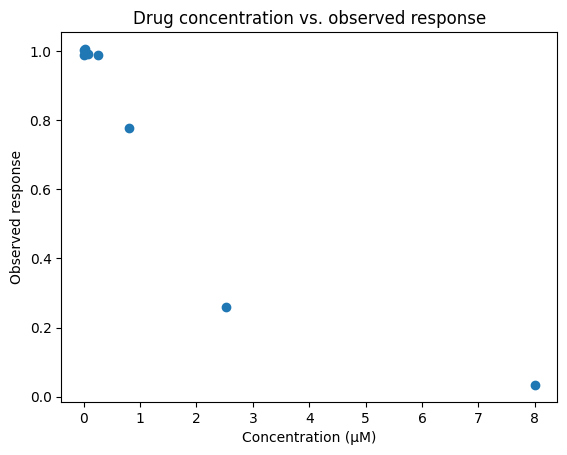

NLL for the chosen parameters: -27.080601885634643
Estimated EC50: 1.5
Estimated h: 2.02
best NLL: -27.116475584494605


In [2]:
# Project card

## The paper
## The data object
## The random variable chosen
## What the paper does
## The generative model proposed
## Parameters and assumptions
## The forward simulation
## The parameterization/fitting
## What/if the model adds to the paper
## Model limitations/how it breaks


# 1. Introduction

# 2. Generative model

## 2.1 Hill model
import matplotlib.pyplot as plt
import random

# Simplify the Hill model to 2 parameters EC50 and h

def mu(c):
  return 1 /(1 + (c / EC50)**h)


## 2.2 Measurement model
# concentration range: 8 µM to 2.5 nM (8 point dose response assays) according to article, values inbetween were chosen arbitrarily

## 2.3 Assumptions
conc = [0.0025, 0.008, 0.025, 0.08, 0.25, 0.80, 2.53, 8] # µM
cancer_types = {
    "Hud": {"EC50": , "h": },
    "Myelom": {"EC50": , "h": },
    "Benmärg": {"EC50": , "h": }
}

mu_E = 0
sigma_E = 0.01

# 3. Forward simulation
observations = []

for c in conc:
  expected_response = mu(c)
  E = random.gauss(mu_E, sigma_E)
  observation = mu(c) + E
  observations.append(observation)


## 3.1 One observation
  print("Concentration:", c, "µM")
  print("Expected response:", expected_response)
  print("Error:", E)
  print("Observed response:", observation)
  print()


## 3.2 Full dose-response experiment
plt.scatter(conc, observations, label = "Simulated observations")
plt.xlabel("Concentration (µM)")
plt.ylabel("Observed response")
plt.title("Drug concentration vs. observed response")
plt.show()


# 4. Parameter estimation
import math

## 4.1 NLL
def nll(observations, theta):
  """NLL(theta) = - sum log p(y_i | theta)."""
  total = 0.0
  EC50, h = theta

  for i in range(len(observations)):
    x = observations[i]
    c = conc[i]

    mu = 1 /(1 + (c / EC50) ** h)

    log_p = (-0.5 * math.log(2 * math.pi * sigma_E**2) - (x - mu)**2 / (2 * sigma_E ** 2))

    total = total - log_p

  return total

theta = (1.5, 2)
result = nll(observations, theta)
print("NLL for the chosen parameters:", result)

## 4.2 MLE
EC50_hat = None
h_hat = None

best = float("inf")

for a in range(201):
  EC50 = 0.5 + 0.01 * a

  for b in range(251):
    h = 0.5 + 0.01 * b

    score = nll(observations, (EC50, h))

    if score < best:
      best = score
      EC50_hat = EC50
      h_hat = h

print("Estimated EC50:", EC50_hat)
print("Estimated h:", h_hat)
print("best NLL:", best)


# true parameters vs estimated parameters


# 5. Parameter recovery

#Repeat simulation 100/500 times.

#Plot:
#EC50 estimates
#h estimates


# 6. Uncertainty

#Parametric bootstrap.

#95% CI for EC50 and h.


# 7. Model failure

#Increase sigma.

#Show:
#noise -> worse parameter recovery


# 8. Discussion

## Interpretation
## Relation to paper
## Limitations
## What model adds


# 9. Conclusion

First observations:

Hud cell line: 0 concentration: 0.0025 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.008 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.025 survivors: 100 true EC50: 0.885
Hud cell line: 0 concentration: 0.08 survivors: 97 true EC50: 0.885
Hud cell line: 0 concentration: 0.25 survivors: 91 true EC50: 0.885
Hud cell line: 0 concentration: 0.8 survivors: 59 true EC50: 0.885
Hud cell line: 0 concentration: 2.53 survivors: 12 true EC50: 0.885
Hud cell line: 0 concentration: 8.0 survivors: 1 true EC50: 0.885
Hud cell line: 1 concentration: 0.0025 survivors: 100 true EC50: 0.612
Hud cell line: 1 concentration: 0.008 survivors: 100 true EC50: 0.612


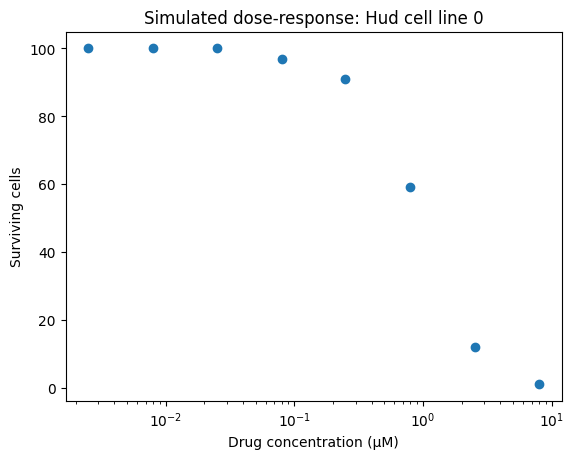

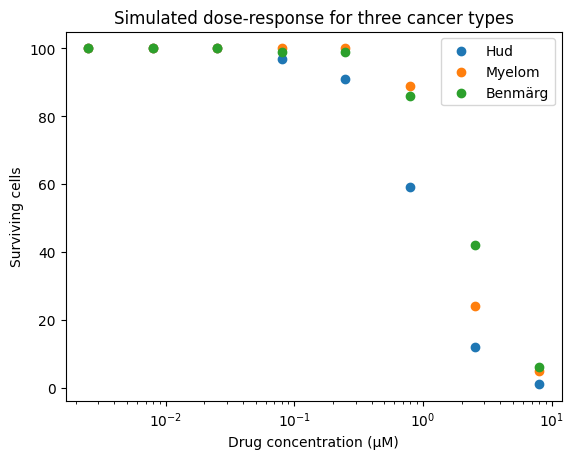


Parameter estimates
--------------------
Hud cell line: 0 | true EC50: 0.885 | estimated EC50: 0.9 | estimated h: 1.81
Hud cell line: 1 | true EC50: 0.612 | estimated EC50: 0.7 | estimated h: 1.94
Hud cell line: 2 | true EC50: 0.879 | estimated EC50: 0.85 | estimated h: 1.91
Hud cell line: 3 | true EC50: 0.886 | estimated EC50: 0.84 | estimated h: 1.78
Hud cell line: 4 | true EC50: 0.67 | estimated EC50: 0.66 | estimated h: 1.89
Hud cell line: 5 | true EC50: 1.621 | estimated EC50: 1.59 | estimated h: 2.0
Hud cell line: 6 | true EC50: 0.609 | estimated EC50: 0.57 | estimated h: 1.98
Hud cell line: 7 | true EC50: 1.153 | estimated EC50: 1.21 | estimated h: 1.85
Hud cell line: 8 | true EC50: 0.695 | estimated EC50: 0.66 | estimated h: 2.0
Hud cell line: 9 | true EC50: 0.887 | estimated EC50: 0.98 | estimated h: 2.0
Myelom cell line: 0 | true EC50: 2.08 | estimated EC50: 1.76 | estimated h: 2.0
Myelom cell line: 1 | true EC50: 1.241 | estimated EC50: 1.36 | estimated h: 2.0
Myelom cell l

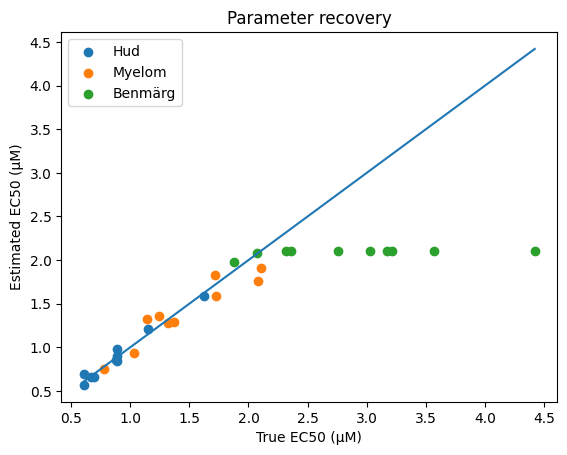


Monte Carlo parameter recovery
-------------------------------
Hud | mean estimated EC50: 1.073
Myelom | mean estimated EC50: 1.657
Benmärg | mean estimated EC50: 2.044


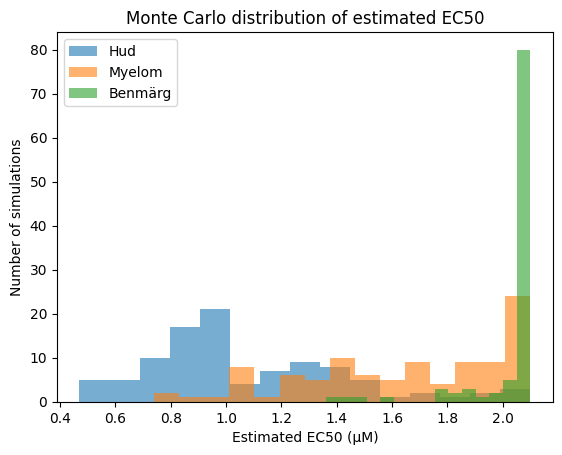

In [7]:
# ============================================================
# PROJECT: Monte Carlo simulation of drug response
# ============================================================

# The model:
#
# p(c) = 1 / (1 + (c / EC50)^h)
#
# Y ~ Binomial(N0, p(c))
#
# Y = number of surviving cells
# c = drug concentration
# EC50 = concentration giving 50% survival
# h = Hill coefficient
# N0 = initial number of cells
#
# The project has three cancer types.
# Each cancer type has its own distribution of EC50 values.
#
# We:
# 1. Simulate EC50 values for cell lines
# 2. Simulate surviving cells using Monte Carlo
# 3. Plot survival against drug concentration
# 4. Estimate EC50 and h using maximum likelihood
# 5. Compare true and estimated parameters
# 6. Repeat the simulation to investigate parameter recovery
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import random
import math
import matplotlib.pyplot as plt


# ============================================================
# 2. Experimental setup
# ============================================================

# Drug concentrations in µM
conc = [
    0.0025,
    0.008,
    0.025,
    0.08,
    0.25,
    0.80,
    2.53,
    8.0
]

# Initial number of cells
N0 = 100

# Hill coefficient
h_true = 2

# Number of cell lines per cancer type
n_cell_lines = 10


# ============================================================
# 3. Cancer types
# ============================================================

# These are hypothetical values for the simulation.
# They are NOT measurements from the paper.

cancer_types = {

    "Skin cancer": {
        "mean_log_EC50": 0.0,
        "sd_log_EC50": 0.30
    },

    "Myeloma": {
        "mean_log_EC50": 0.5,
        "sd_log_EC50": 0.30
    },

    "Breast cancer": {
        "mean_log_EC50": 1.0,
        "sd_log_EC50": 0.30
    }
}


# ============================================================
# 4. Hill model
# ============================================================

def hill(c, EC50, h):

    return 1 / (1 + (c / EC50) ** h)


# ============================================================
# 5. Monte Carlo simulation of surviving cells
# ============================================================

def simulate_survivors(N0, survival_probability):

    survivors = 0

    for cell in range(N0):

        # Random number between 0 and 1
        r = random.random()

        if r < survival_probability:
            survivors += 1

    return survivors


# ============================================================
# 6. Generate one cell line
# ============================================================

def simulate_cell_line(EC50, h):

    observations = []

    for c in conc:

        # Expected probability of survival
        p = hill(c, EC50, h)

        # Monte Carlo simulation of individual cells
        survivors = simulate_survivors(
            N0,
            p
        )

        observations.append({
            "concentration": c,
            "survivors": survivors
        })

    return observations


# ============================================================
# 7. Generate the complete dataset
# ============================================================

data = []


for cancer_type, parameters in cancer_types.items():

    for cell_number in range(n_cell_lines):

        # Draw EC50 for this cell line
        log_EC50 = random.gauss(
            parameters["mean_log_EC50"],
            parameters["sd_log_EC50"]
        )

        EC50 = math.exp(log_EC50)

        # Simulate dose-response experiment
        observations = simulate_cell_line(
            EC50,
            h_true
        )

        # Store every observation
        for observation in observations:

            data.append({
                "cancer_type": cancer_type,
                "cell_line": cell_number,
                "concentration": observation["concentration"],
                "survivors": observation["survivors"],
                "EC50_true": EC50
            })


# ============================================================
# 8. Inspect simulated data
# ============================================================

print("First observations:")
print()

for row in data[:10]:

    print(
        row["cancer_type"],
        "cell line:", row["cell_line"],
        "concentration:", row["concentration"],
        "survivors:", row["survivors"],
        "true EC50:", round(row["EC50_true"], 3)
    )


# ============================================================
# 9. Plot dose-response for one cell line
# ============================================================

def get_cell_line(data, cancer_type, cell_number):

    observations = []

    for row in data:

        if (
            row["cancer_type"] == cancer_type
            and row["cell_line"] == cell_number
        ):

            observations.append(row)

    return observations


example_data = get_cell_line(
    data,
    "Hud",
    0
)


x = []
y = []

for row in example_data:

    x.append(row["concentration"])
    y.append(row["survivors"])


plt.scatter(x, y)

plt.xscale("log")

plt.xlabel("Drug concentration (µM)")
plt.ylabel("Surviving cells")
plt.title("Simulated dose-response: Hud cell line 0")

plt.show()


# ============================================================
# 10. Plot all three cancer types
# ============================================================

for cancer_type in cancer_types:

    observations = get_cell_line(
        data,
        cancer_type,
        0
    )

    x = []
    y = []

    for row in observations:

        x.append(row["concentration"])
        y.append(row["survivors"])

    plt.scatter(
        x,
        y,
        label=cancer_type
    )


plt.xscale("log")

plt.xlabel("Drug concentration (µM)")
plt.ylabel("Surviving cells")
plt.title("Simulated dose-response for three cancer types")

plt.legend()

plt.show()


# ============================================================
# 11. Negative log likelihood
# ============================================================

def log_binomial_probability(N, Y, p):

    # Avoid log(0)
    if p <= 0:
        p = 1e-10

    if p >= 1:
        p = 1 - 1e-10

    # log of binomial coefficient
    log_combination = (
        math.lgamma(N + 1)
        - math.lgamma(Y + 1)
        - math.lgamma(N - Y + 1)
    )

    return (
        log_combination
        + Y * math.log(p)
        + (N - Y) * math.log(1 - p)
    )


def nll(observations, EC50, h):

    total = 0.0

    for row in observations:

        c = row["concentration"]
        Y = row["survivors"]

        p = hill(
            c,
            EC50,
            h
        )

        log_p = log_binomial_probability(
            N0,
            Y,
            p
        )

        total = total - log_p

    return total


# ============================================================
# 12. Maximum likelihood estimation
# ============================================================

def fit_cell_line(observations):

    best = float("inf")

    EC50_hat = None
    h_hat = None

    # Search over possible EC50 values
    for a in range(201):

        EC50 = 0.1 + 0.01 * a

        # Search over possible Hill coefficients
        for b in range(151):

            h = 0.5 + 0.01 * b

            score = nll(
                observations,
                EC50,
                h
            )

            if score < best:

                best = score
                EC50_hat = EC50
                h_hat = h

    return EC50_hat, h_hat, best


# ============================================================
# 13. Fit all cell lines
# ============================================================

results = []


for cancer_type in cancer_types:

    for cell_number in range(n_cell_lines):

        observations = get_cell_line(
            data,
            cancer_type,
            cell_number
        )

        EC50_hat, h_hat, best_nll = fit_cell_line(
            observations
        )

        EC50_true = observations[0]["EC50_true"]

        results.append({
            "cancer_type": cancer_type,
            "cell_line": cell_number,
            "EC50_true": EC50_true,
            "EC50_hat": EC50_hat,
            "h_hat": h_hat,
            "NLL": best_nll
        })


# ============================================================
# 14. Print parameter estimates
# ============================================================

print()
print("Parameter estimates")
print("--------------------")

for result in results:

    print(
        result["cancer_type"],
        "cell line:", result["cell_line"],
        "| true EC50:",
        round(result["EC50_true"], 3),
        "| estimated EC50:",
        round(result["EC50_hat"], 3),
        "| estimated h:",
        round(result["h_hat"], 2)
    )


# ============================================================
# 15. Plot true vs estimated EC50
# ============================================================

for cancer_type in cancer_types:

    true_values = []
    estimated_values = []

    for result in results:

        if result["cancer_type"] == cancer_type:

            true_values.append(
                result["EC50_true"]
            )

            estimated_values.append(
                result["EC50_hat"]
            )

    plt.scatter(
        true_values,
        estimated_values,
        label=cancer_type
    )


# Reference line y = x
minimum = min(
    [result["EC50_true"] for result in results]
)

maximum = max(
    [result["EC50_true"] for result in results]
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("True EC50 (µM)")
plt.ylabel("Estimated EC50 (µM)")
plt.title("Parameter recovery")

plt.legend()

plt.show()


# ============================================================
# 16. Monte Carlo parameter recovery
# ============================================================

# Number of repeated experiments
n_simulations = 100

recovery = {}


for cancer_type in cancer_types:

    recovery[cancer_type] = []


for simulation in range(n_simulations):

    for cancer_type, parameters in cancer_types.items():

        # Generate one new cell line
        log_EC50 = random.gauss(
            parameters["mean_log_EC50"],
            parameters["sd_log_EC50"]
        )

        EC50_true = math.exp(log_EC50)

        observations = simulate_cell_line(
            EC50_true,
            h_true
        )

        # Add the true EC50 to each observation
        formatted_observations = []

        for observation in observations:

            formatted_observations.append({
                "concentration": observation["concentration"],
                "survivors": observation["survivors"]
            })

        # Estimate parameters
        EC50_hat, h_hat, best_nll = fit_cell_line(
            formatted_observations
        )

        recovery[cancer_type].append({
            "EC50_true": EC50_true,
            "EC50_hat": EC50_hat,
            "h_hat": h_hat
        })


# ============================================================
# 17. Summarize Monte Carlo results
# ============================================================

print()
print("Monte Carlo parameter recovery")
print("-------------------------------")

for cancer_type in cancer_types:

    estimates = []

    for result in recovery[cancer_type]:

        estimates.append(
            result["EC50_hat"]
        )

    mean_estimate = (
        sum(estimates) / len(estimates)
    )

    print(
        cancer_type,
        "| mean estimated EC50:",
        round(mean_estimate, 3)
    )


# ============================================================
# 18. Plot EC50 distributions
# ============================================================

for cancer_type in cancer_types:

    estimates = []

    for result in recovery[cancer_type]:

        estimates.append(
            result["EC50_hat"]
        )

    plt.hist(
        estimates,
        bins=15,
        alpha=0.6,
        label=cancer_type
    )


plt.xlabel("Estimated EC50 (µM)")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo distribution of estimated EC50")

plt.legend()

plt.show()

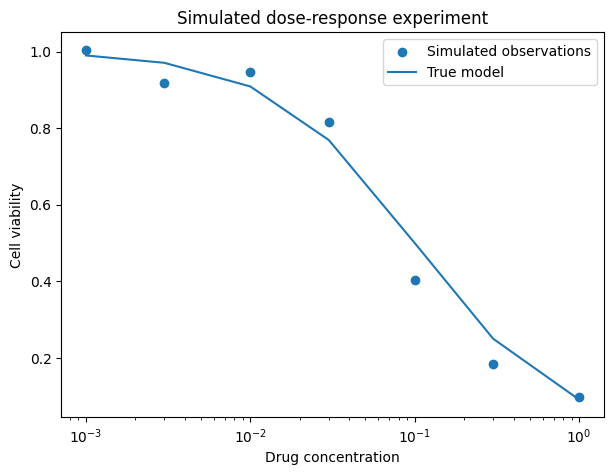

Parameter estimation
--------------------
True EC50:       0.1000
Estimated EC50:  0.0847
Optimization OK: True


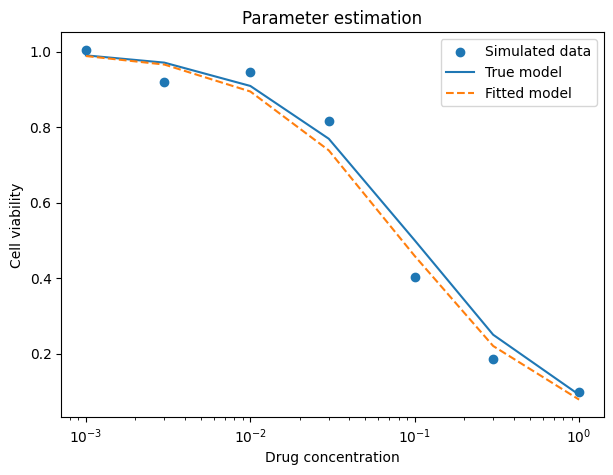

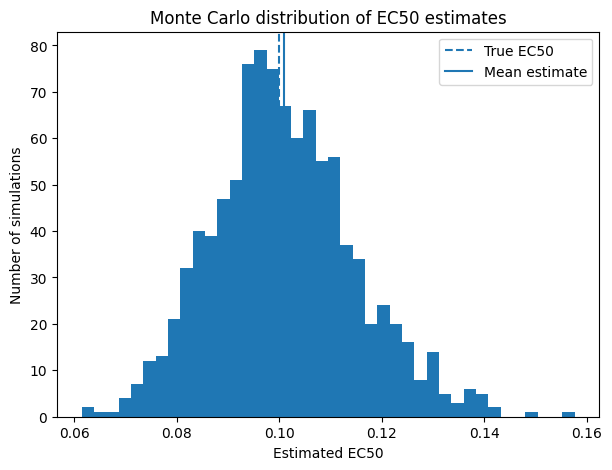


Monte Carlo results
-------------------
True EC50:           0.1000
Mean estimated EC50: 0.1010
Std of estimates:    0.0139
95% range:           [0.0756, 0.1306]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ============================================================
# 1. GENERATIVE MODEL
# ============================================================

def dose_response(concentration, EC50):
    """
    Expected cell viability as a function of drug concentration.
    """
    return 1 / (1 + concentration / EC50)


# ============================================================
# 2. SIMULATION SETTINGS
# ============================================================

rng = np.random.default_rng(42)

EC50_true = 0.1
sigma = 0.05

concentrations = np.array([
    0.001,
    0.003,
    0.01,
    0.03,
    0.1,
    0.3,
    1.0
])


# ============================================================
# 3. FORWARD SIMULATION
# ============================================================

true_response = dose_response(
    concentrations,
    EC50_true
)

observed_response = rng.normal(
    loc=true_response,
    scale=sigma
)


# ============================================================
# 4. PLOT SIMULATED EXPERIMENT
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    concentrations,
    observed_response,
    label="Simulated observations"
)

plt.plot(
    concentrations,
    true_response,
    label="True model"
)

plt.xscale("log")

plt.xlabel("Drug concentration")
plt.ylabel("Cell viability")
plt.title("Simulated dose-response experiment")

plt.legend()
plt.show()


# ============================================================
# 5. NEGATIVE LOG-LIKELIHOOD
# ============================================================

def negative_log_likelihood(
    log_EC50,
    concentrations,
    observations,
    sigma
):
    """
    Negative log-likelihood.

    We optimize log(EC50), rather than EC50 itself.
    This guarantees that EC50 is always positive.
    """

    # Convert back from log-space
    EC50 = np.exp(log_EC50[0])

    predicted = dose_response(
        concentrations,
        EC50
    )

    residuals = observations - predicted

    n = len(observations)

    nll = (
        0.5 * n * np.log(2 * np.pi * sigma**2)
        + np.sum(residuals**2) / (2 * sigma**2)
    )

    return nll


# ============================================================
# 6. PARAMETER ESTIMATION
# ============================================================

initial_EC50 = 0.2

result = minimize(
    negative_log_likelihood,
    x0=[np.log(initial_EC50)],
    args=(
        concentrations,
        observed_response,
        sigma
    ),
    method="BFGS"
)

# Convert back from log-space
EC50_estimated = np.exp(result.x[0])


print("Parameter estimation")
print("--------------------")
print(f"True EC50:       {EC50_true:.4f}")
print(f"Estimated EC50:  {EC50_estimated:.4f}")
print(f"Optimization OK: {result.success}")


# ============================================================
# 7. PLOT FITTED MODEL
# ============================================================

fitted_response = dose_response(
    concentrations,
    EC50_estimated
)

plt.figure(figsize=(7, 5))

plt.scatter(
    concentrations,
    observed_response,
    label="Simulated data"
)

plt.plot(
    concentrations,
    true_response,
    label="True model"
)

plt.plot(
    concentrations,
    fitted_response,
    "--",
    label="Fitted model"
)

plt.xscale("log")

plt.xlabel("Drug concentration")
plt.ylabel("Cell viability")
plt.title("Parameter estimation")

plt.legend()
plt.show()


# ============================================================
# 8. MONTE CARLO SIMULATION
# ============================================================

n_simulations = 1000

estimated_EC50s = []

for _ in range(n_simulations):

    # Generate a new experiment
    simulated_observations = rng.normal(
        loc=dose_response(
            concentrations,
            EC50_true
        ),
        scale=sigma
    )

    # Estimate EC50
    result = minimize(
        negative_log_likelihood,
        x0=[np.log(0.2)],
        args=(
            concentrations,
            simulated_observations,
            sigma
        ),
        method="BFGS"
    )

    # Store estimate
    estimated_EC50s.append(
        np.exp(result.x[0])
    )


estimated_EC50s = np.array(
    estimated_EC50s
)


# ============================================================
# 9. MONTE CARLO DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    estimated_EC50s,
    bins=40
)

plt.axvline(
    EC50_true,
    linestyle="--",
    label="True EC50"
)

plt.axvline(
    np.mean(estimated_EC50s),
    label="Mean estimate"
)

plt.xlabel("Estimated EC50")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo distribution of EC50 estimates")

plt.legend()
plt.show()


# ============================================================
# 10. SUMMARY
# ============================================================

mean_estimate = np.mean(estimated_EC50s)
std_estimate = np.std(estimated_EC50s)

lower = np.percentile(
    estimated_EC50s,
    2.5
)

upper = np.percentile(
    estimated_EC50s,
    97.5
)

print("\nMonte Carlo results")
print("-------------------")
print(f"True EC50:           {EC50_true:.4f}")
print(f"Mean estimated EC50: {mean_estimate:.4f}")
print(f"Std of estimates:    {std_estimate:.4f}")
print(f"95% range:           [{lower:.4f}, {upper:.4f}]")